# Intelligent Agents: Reflex-Based Agents for GridHunt (Multi-agent Environment)

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and several hunter agents and the monster agent move around in the arena. A hunter catches the monster if she/he moves on the same square the monster currently occupies. The hunters compete fow who catches the monster first. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunters are randomly placed in the arena environment. The hunters and the monster
    can move around, but cannot leave the arena. Since there are three agents involved, this is a competitive multi-agent environment.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena and the location of the monster.  

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [1]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_1_agent_function, hunter_2_agent_function, monster_agent_function, n = 30, max_steps = 100, visualize = False, animation = False):
    """
    Simulate an arena where two hunter agent tries to catch a monster agent.

    Parameters:
    hunter_1_agent_function and hunter_2_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_1_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_1_pos, monster_pos):
        hunter_1_pos = np.random.randint(0, n-1, size=2)
    hunter_2_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_2_pos, monster_pos):
        hunter_2_pos = np.random.randint(0, n-1, size=2)    
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step}:")
        print(f"Hunter 1 is at '{hunter_1_pos}'; Hunter 2 is at '{hunter_2_pos}'; Monster is at '{monster_pos}'\n")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_1_pos[0], hunter_1_pos[1]] = '1'
        arena[hunter_2_pos[0], hunter_2_pos[1]] = '2'
        print("\n".join("".join(row) for row in arena))

    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_1_pos, monster_pos):
            if visualize:
                print(f"Hunter 1 caught the monster in {step} steps!")
            return ("1", step)
        
        if np.array_equal(hunter_2_pos, monster_pos):
            if visualize:
                print(f"Hunter 2 caught the monster in {step} steps!")
            return ("2", step)

        # Get next move from monster agent function
        monster_action = monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos)
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function
        hunter_1_action = hunter_1_agent_function(hunter_1_pos, monster_pos)
        if hunter_1_action == 'teleport':
            hunter_1_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_1_pos = move(hunter_1_action, hunter_1_pos)

        hunter_2_action = hunter_2_agent_function(hunter_2_pos, monster_pos)
        if hunter_2_action == 'teleport':
            hunter_2_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_2_pos = move(hunter_2_action, hunter_2_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter 1 chose action '{hunter_1_action}'")
            print(f"Hunter 2 chose action '{hunter_2_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n" + "="*n + "\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Monster won by surviving {max_steps} steps.")
    
    return ("M", np.nan)

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [2]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(monster_pos, hunter_1_pos, hunter_2_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [3]:
actions = ["north", "east", "west", "south", "teleport"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [4]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [5]:
simple_randomized_hunter_agent_function([0,0], [5,5])

np.str_('east')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [6]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=5, max_steps=5, visualize=True, animation=False)

Step 0:
Hunter 1 is at '[2 3]'; Hunter 2 is at '[3 0]'; Monster is at '[3 1]'

.....
.....
...1.
2M...
.....
Hunter 1 chose action 'south'
Hunter 2 chose action 'teleport'
Monster chose action 'stay'

=====

Step 1:
Hunter 1 is at '[3 3]'; Hunter 2 is at '[3 0]'; Monster is at '[3 1]'

.....
.....
.....
2M.1.
.....
Hunter 1 chose action 'teleport'
Hunter 2 chose action 'east'
Monster chose action 'stay'

=====

Step 2:
Hunter 1 is at '[1 2]'; Hunter 2 is at '[3 1]'; Monster is at '[3 1]'

.....
..1..
.....
.2...
.....
Hunter 2 caught the monster in 2 steps!


('2', 2)

### Trực quan hóa Đồ họa Pixel-Art trên lưới 5x5 (Nguyên bản như ảnh mẫu)
Bạn có thể phát hoạt họa tương tác với giao diện Pixel Art chuẩn như ảnh đề bài:


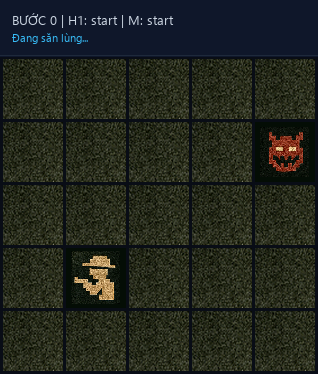
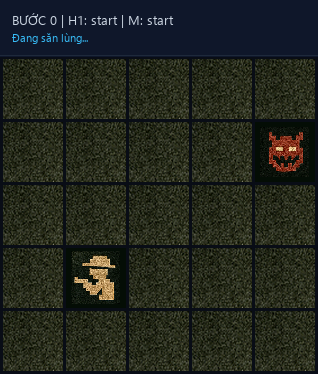
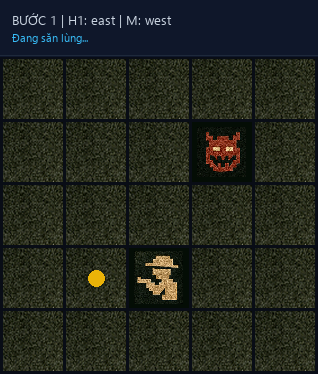
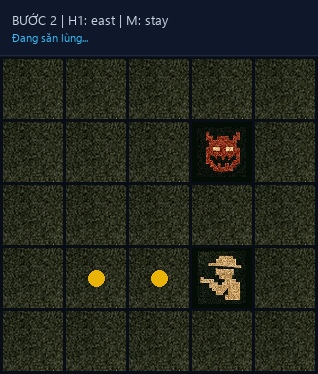
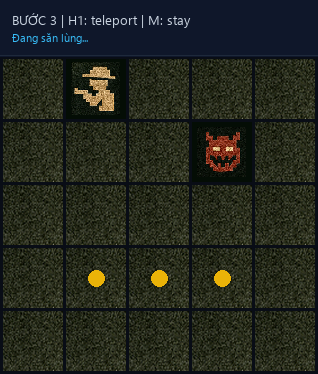
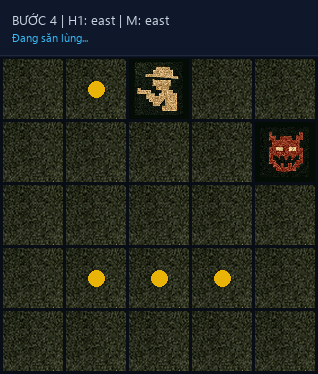
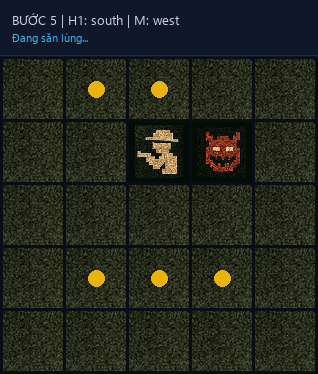
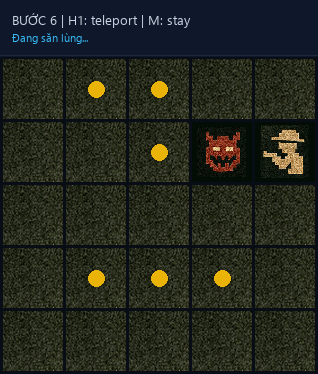
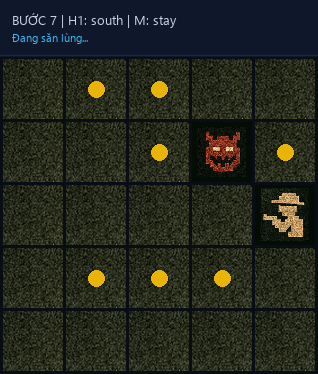
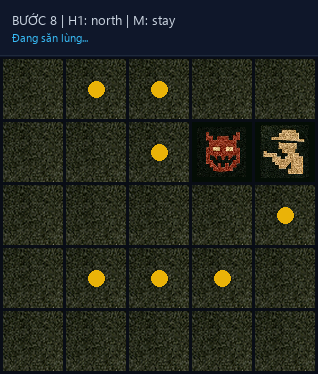
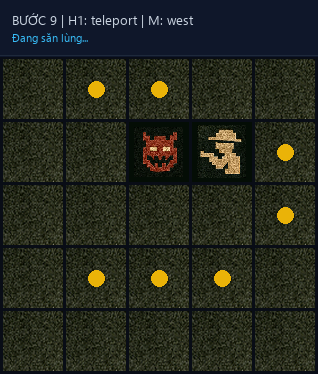
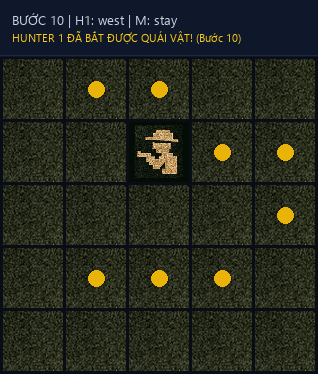

In [7]:
from gridhunt_visualizer import play_gridhunt

# Mô phỏng lưới 5x5 nguyên bản 1 Thợ săn vs 1 Quái vật:
play_gridhunt(
    hunter_1_func=simple_randomized_hunter_agent_function,
    hunter_2_func=None,
    monster_func=monster_agent_function_simple,
    n=5,
    max_steps=20
)

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $20 \times 20$ arena.  

In [8]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

steps = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[('2', 75), ('M', nan), ('M', nan), ('M', nan), ('2', 59), ('1', 67), ('M', nan), ('M', nan), ('M', nan), ('2', 48), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 34), ('2', 52), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 84), ('2', 3), ('1', 55), ('M', nan), ('2', 17), ('M', nan), ('2', 5), ('M', nan), ('1', 19), ('2', 23), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 29), ('M', nan), ('2', 52), ('2', 82), ('M', nan), ('2', 66), ('M', nan), ('M', nan), ('2', 39), ('1', 24), ('M', nan), ('M', nan), ('1', 94), ('M', nan), ('M', nan), ('M', nan), ('2', 93), ('1', 57), ('M', nan), ('M', nan), ('1', 25), ('1', 76), ('M', nan), ('M', nan), ('2', 3), ('M', nan), ('M', nan), ('2', 62), ('M', nan), ('M', nan), ('2', 46), ('M', nan), ('M', nan), ('1', 76), ('1', 79), ('M', nan), ('M', nan),

We just got a list with who one and the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results by counting who won how often.

In [9]:
steps = np.array(steps)

print (f"Hunter 1 won: {np.sum(steps[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps[:,0] == 'M')}")       


Hunter 1 won: 13
Hunter 2 won: 20
Monster 1 won: 67


The random agent in not a very good hunter. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and modify it using rules based on the monster's and the hunter's location. Let your hunter compete with the random agent. You can also come up with several different agents and let them compete against each other.

In [10]:
# 1. SMART HUNTER (Graeedy Manhattan Reflex - Không Teleport)

def smart_hunter_agent_function(hunter_location, monster_location):
    """ Reflex Agent : Di chuyển theo thuật toán Manhattan, 
        ưu tiên trục có độ lêch lớn hơn để tiếp cận Monster nhanh nhất.
    """

    d_row = monster_location[0] - hunter_location[0]
    d_col = monster_location[1] - hunter_location[1]

    if d_row == 0 and d_col == 0:
        return "north"
    
    row_action = "north" if d_row < 0 else "south"
    col_action = "west" if d_col < 0 else "east"

    if d_row == 0:
        return col_action
    if d_col == 0:
        return row_action
    
    if abs(d_row) > abs(d_col):
        return row_action
    elif abs(d_row) < abs(d_col):
        return col_action
    else :
        return np.random.choice([row_action, col_action])
    

In [11]:
# 2. TELEPORT HUNTER (Được phép teleport khi khoảng cách quá xa)
def teleport_hunter_agent_function(hunter_location, monster_location):
    """ Reflex Agent có điều kiện cho Teleport:
        
        Nếu ở quá xa, có 30% xác suất cơ hội teleport để thư vận may có
        áp sát được mục tiêu hay không. Nếu ở gần thì vẫn giữ nguyên sử 
        dụng thuật toán Manhattan để tiếp cận mục tiêu.
    """

    d_row = monster_location[0] - hunter_location[0]
    d_col = monster_location[1] - hunter_location[1]
    manhattan_dist = abs(d_row) + abs(d_col)

    if manhattan_dist > 15 and np.random.rand() <= 0.3:
        return "teleport"
    
    return smart_hunter_agent_function(hunter_location, monster_location)



# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

In [12]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = smart_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=20, max_steps=100, visualize=True, animation=True)

Step 15:
Hunter 1 is at '[ 2 14]'; Hunter 2 is at '[ 8 11]'; Monster is at '[ 8 11]'

....................
....................
..............1.....
....................
....................
....................
....................
....................
...........2........
....................
....................
....................
....................
....................
....................
....................
....................
....................
....................
....................
Hunter 2 caught the monster in 15 steps!


('2', 15)

In [13]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps1 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps1)

[('2', 5), ('2', 17), ('2', 21), ('1', 11), ('2', 14), ('2', 10), ('2', 19), ('2', 18), ('2', 10), ('2', 9), ('2', 22), ('2', 9), ('2', 18), ('2', 9), ('2', 19), ('2', 23), ('2', 13), ('2', 4), ('2', 9), ('2', 6), ('2', 12), ('2', 8), ('2', 18), ('2', 22), ('2', 13), ('2', 2), ('2', 18), ('2', 14), ('2', 25), ('2', 7), ('2', 11), ('2', 9), ('2', 12), ('2', 11), ('2', 16), ('2', 12), ('2', 9), ('2', 13), ('2', 12), ('2', 20), ('2', 12), ('2', 21), ('2', 7), ('2', 9), ('2', 25), ('2', 19), ('2', 8), ('2', 11), ('2', 18), ('2', 2), ('2', 16), ('2', 13), ('2', 15), ('1', 7), ('2', 3), ('2', 12), ('2', 12), ('1', 1), ('2', 7), ('2', 9), ('1', 2), ('2', 25), ('2', 13), ('2', 9), ('2', 15), ('2', 16), ('2', 18), ('2', 6), ('2', 18), ('2', 5), ('2', 14), ('2', 10), ('2', 21), ('2', 19), ('2', 24), ('2', 9), ('2', 19), ('2', 9), ('2', 11), ('2', 14), ('2', 9), ('2', 17), ('2', 3), ('2', 13), ('2', 19), ('2', 11), ('2', 10), ('2', 7), ('2', 5), ('2', 7), ('2', 19), ('2', 4), ('2', 8), ('2', 14),

In [14]:
steps1 = np.array(steps1)

print (f"Hunter 1 won: {np.sum(steps1[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps1[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps1[:,0] == 'M')}")       


Hunter 1 won: 4
Hunter 2 won: 96
Monster 1 won: 0


In [58]:
hunter_1 = teleport_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps2 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=15, max_steps=100, visualize=False) for _ in range(100)] 
print(steps2)

[('2', 1), ('1', 16), ('1', 7), ('1', 6), ('1', 10), ('2', 8), ('1', 1), ('1', 8), ('2', 9), ('1', 11), ('2', 3), ('2', 6), ('2', 5), ('1', 9), ('1', 7), ('2', 7), ('2', 9), ('2', 7), ('2', 12), ('2', 13), ('1', 3), ('1', 9), ('2', 10), ('2', 11), ('1', 7), ('1', 4), ('2', 10), ('2', 4), ('1', 7), ('1', 8), ('1', 5), ('2', 3), ('2', 15), ('1', 5), ('1', 8), ('2', 9), ('1', 3), ('1', 16), ('1', 4), ('2', 2), ('1', 7), ('1', 12), ('1', 6), ('1', 4), ('1', 17), ('1', 2), ('2', 4), ('1', 4), ('1', 2), ('1', 3), ('1', 6), ('1', 6), ('2', 14), ('2', 2), ('2', 11), ('2', 10), ('1', 7), ('1', 7), ('2', 5), ('2', 15), ('1', 1), ('2', 8), ('2', 6), ('2', 12), ('2', 3), ('1', 14), ('1', 1), ('2', 10), ('1', 7), ('1', 9), ('1', 8), ('2', 5), ('1', 5), ('1', 9), ('1', 8), ('1', 7), ('2', 3), ('1', 3), ('1', 12), ('1', 16), ('1', 3), ('2', 4), ('2', 4), ('2', 11), ('1', 6), ('2', 7), ('1', 9), ('2', 11), ('2', 9), ('2', 7), ('1', 4), ('1', 5), ('2', 6), ('2', 6), ('1', 2), ('1', 7), ('1', 4), ('1', 

In [59]:
steps2 = np.array(steps2)

print (f"Hunter 1 won: {np.sum(steps2[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps2[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps2[:,0] == 'M')}")       


Hunter 1 won: 57
Hunter 2 won: 43
Monster 1 won: 0


In [50]:
hunter_1 = teleport_hunter_agent_function
hunter_2 = smart_hunter_agent_function

steps3 = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=30, max_steps=100, visualize=False) for _ in range(100)] 
print(steps3)

[('2', 5), ('2', 4), ('1', 5), ('2', 5), ('1', 14), ('1', 7), ('1', 19), ('1', 15), ('1', 10), ('1', 17), ('1', 10), ('1', 6), ('2', 7), ('1', 9), ('1', 16), ('2', 11), ('1', 2), ('1', 3), ('2', 17), ('1', 11), ('2', 9), ('1', 8), ('1', 6), ('2', 18), ('1', 13), ('1', 14), ('1', 7), ('2', 9), ('1', 15), ('1', 22), ('1', 19), ('1', 12), ('1', 16), ('1', 10), ('1', 15), ('2', 8), ('1', 17), ('1', 20), ('2', 12), ('1', 4), ('1', 17), ('1', 12), ('1', 9), ('1', 5), ('2', 10), ('1', 18), ('1', 6), ('1', 12), ('2', 10), ('1', 16), ('1', 3), ('1', 8), ('1', 7), ('1', 8), ('1', 13), ('1', 7), ('1', 11), ('1', 25), ('1', 12), ('2', 8), ('1', 5), ('1', 13), ('1', 6), ('1', 10), ('1', 11), ('1', 12), ('1', 25), ('1', 16), ('1', 18), ('2', 17), ('1', 11), ('2', 12), ('2', 20), ('1', 15), ('2', 12), ('2', 13), ('1', 8), ('2', 5), ('2', 5), ('1', 9), ('1', 12), ('1', 22), ('1', 22), ('2', 21), ('2', 3), ('2', 8), ('1', 19), ('1', 17), ('2', 13), ('1', 19), ('1', 9), ('1', 17), ('1', 26), ('1', 12), 

In [51]:
steps3 = np.array(steps3)

print (f"Hunter 1 won: {np.sum(steps3[:,0] == '1')}")
print (f"Hunter 2 won: {np.sum(steps3[:,0] == '2')}")
print (f"Monster 1 won: {np.sum(steps3[:,0] == 'M')}")       


Hunter 1 won: 71
Hunter 2 won: 29
Monster 1 won: 0


### Trực quan hóa Đồ họa Pixel-Art (Interactive Visualizer)
Mô phỏng đồ họa Pixel-Art sinh động trực tiếp trong Notebook với đầy đủ bộ điều khiển: Play, Pause, Tua từng bước, Thanh trượt Scrubber và Chỉnh tốc độ:


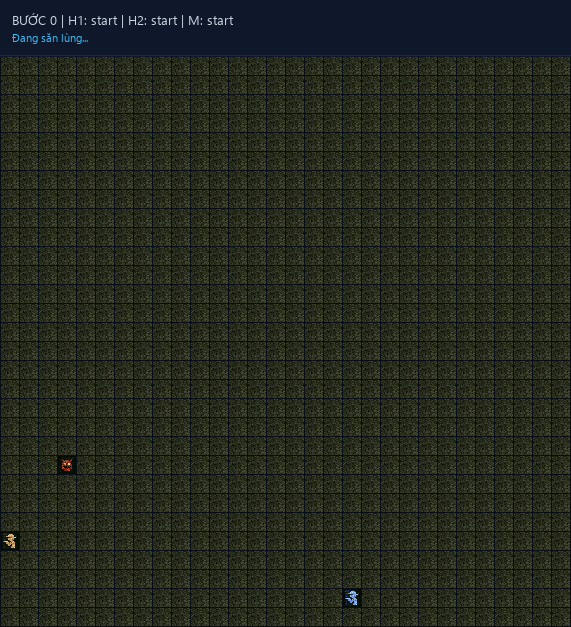
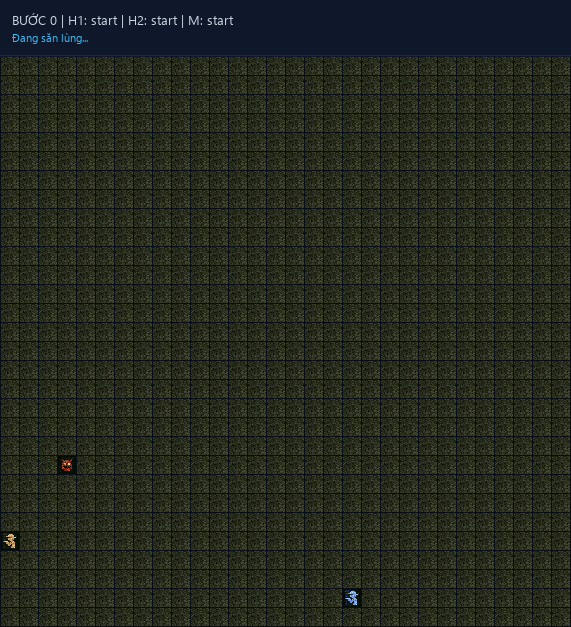
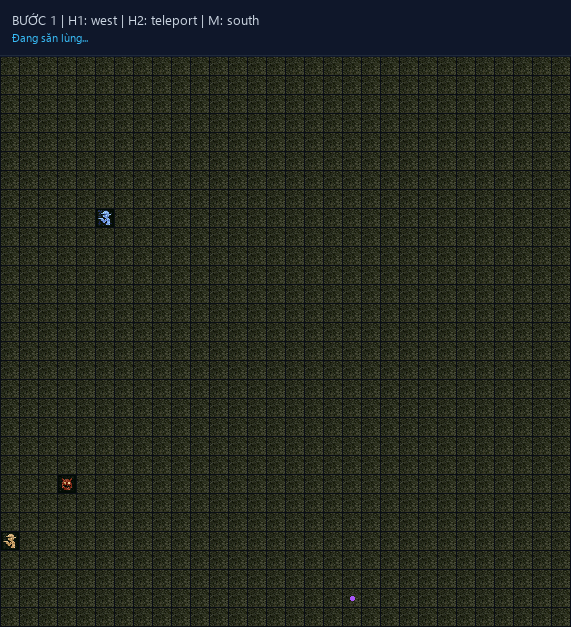
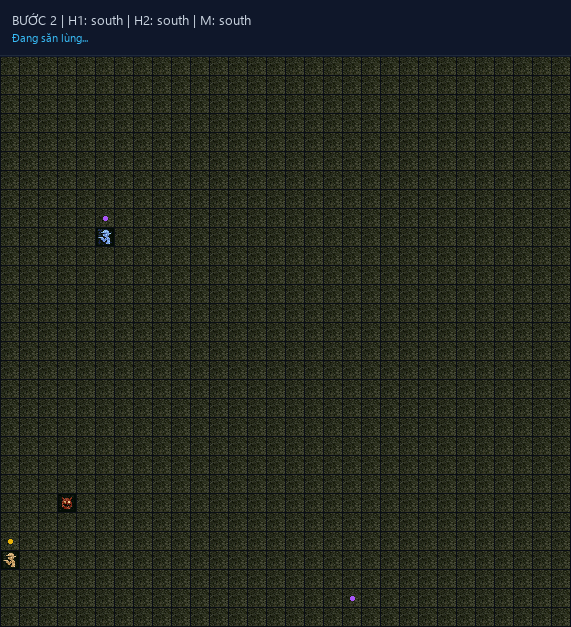
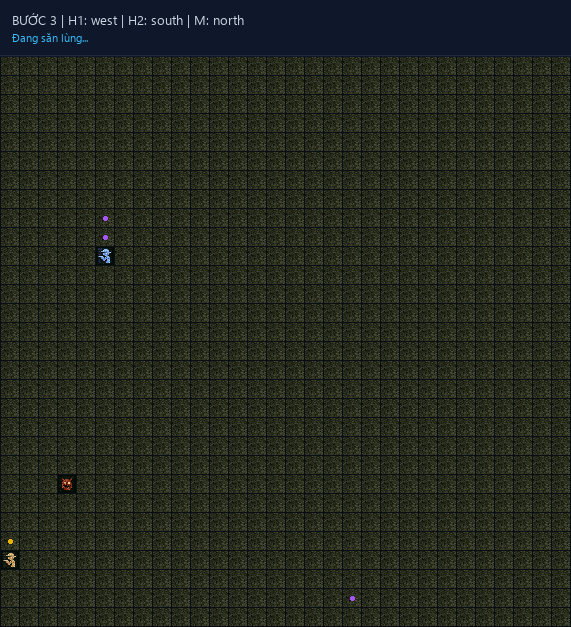
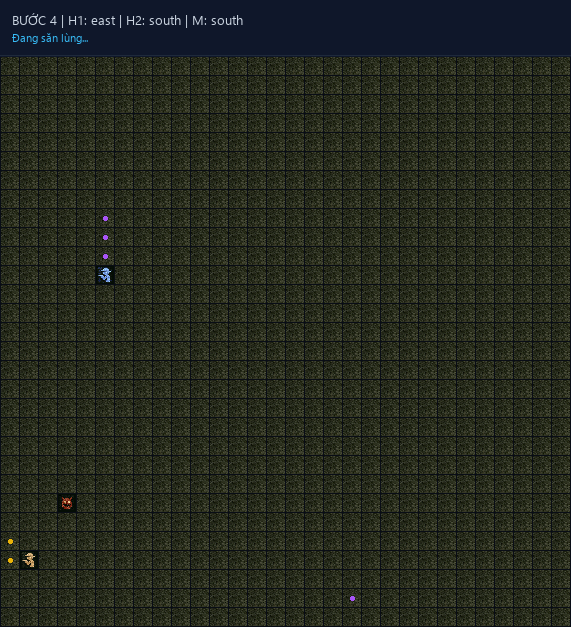
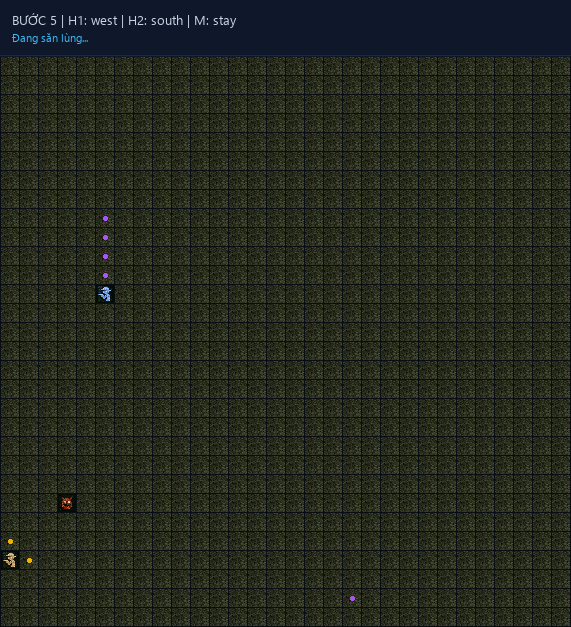
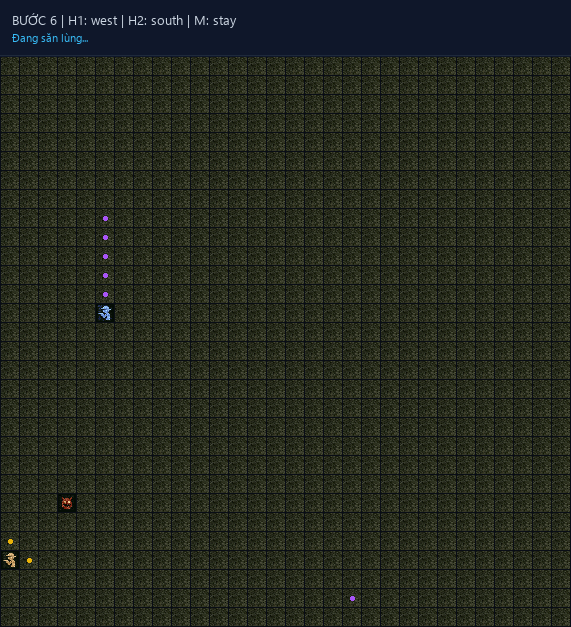
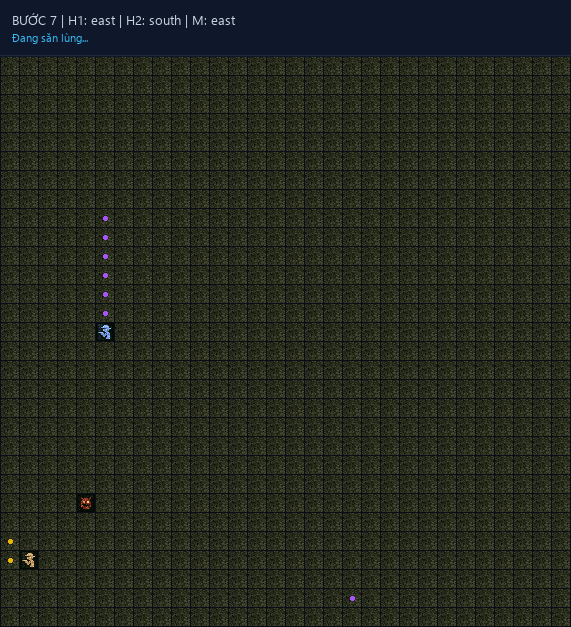
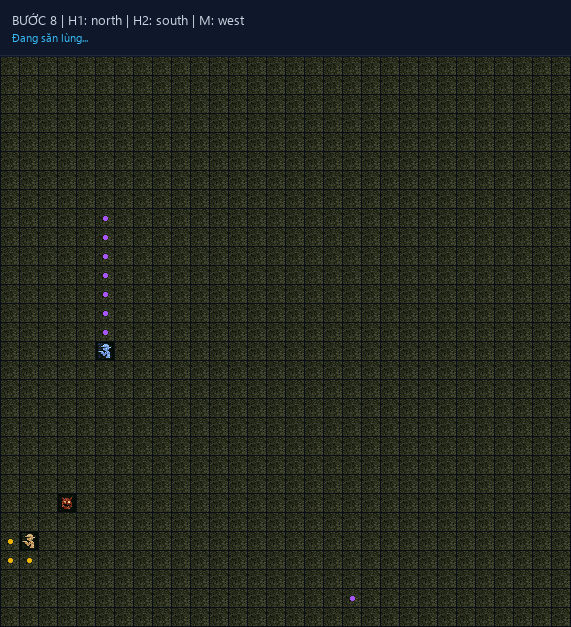
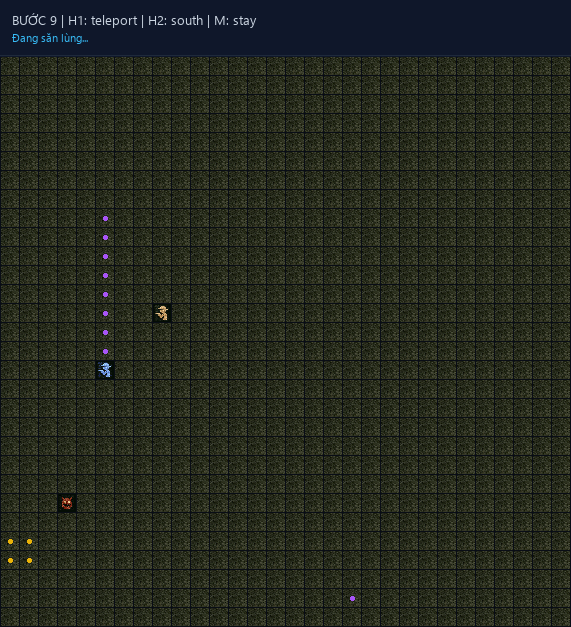
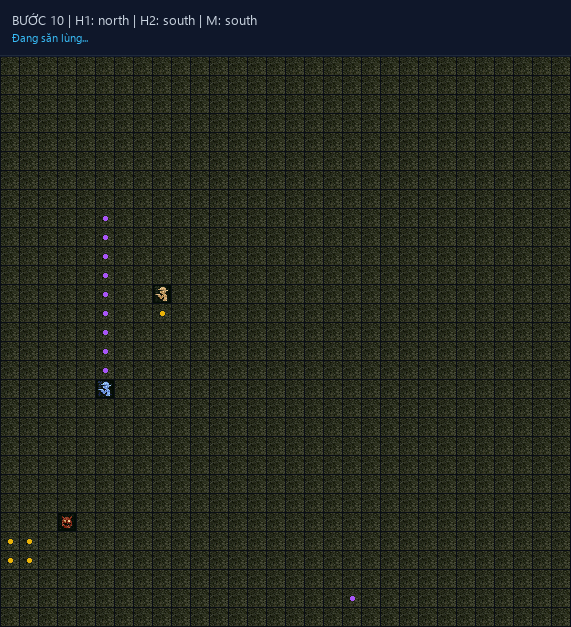
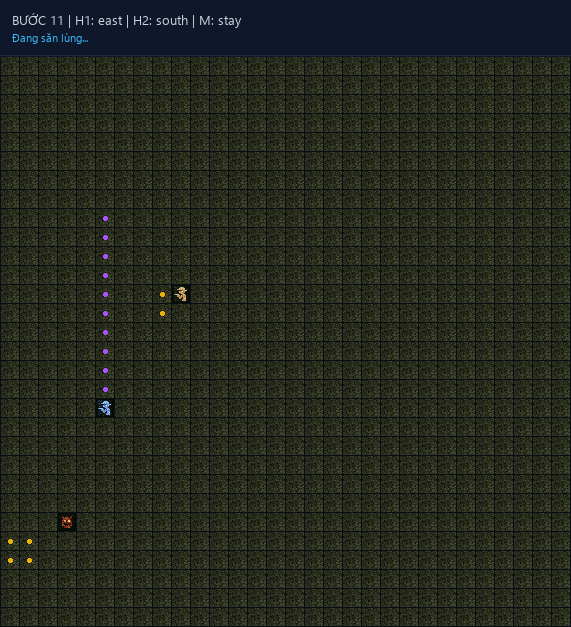
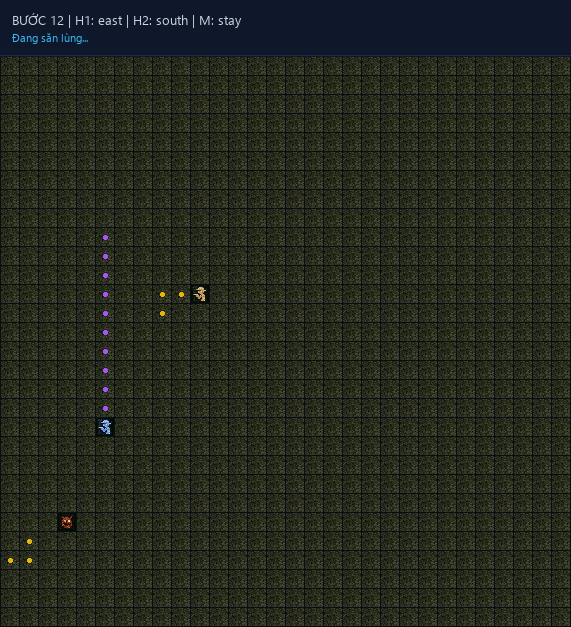
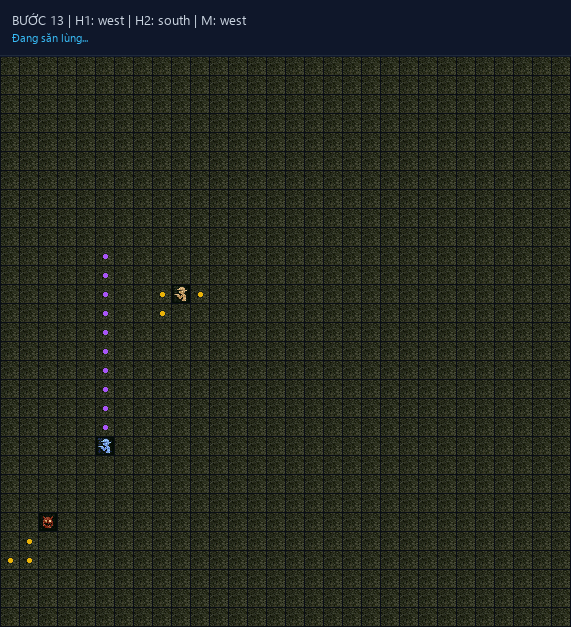
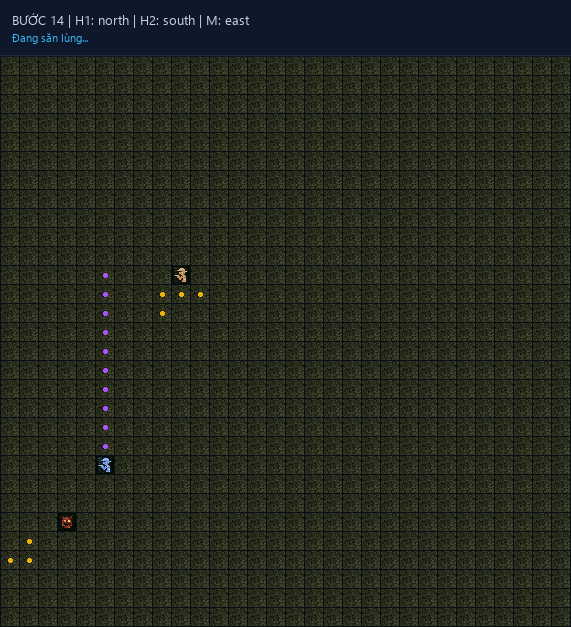
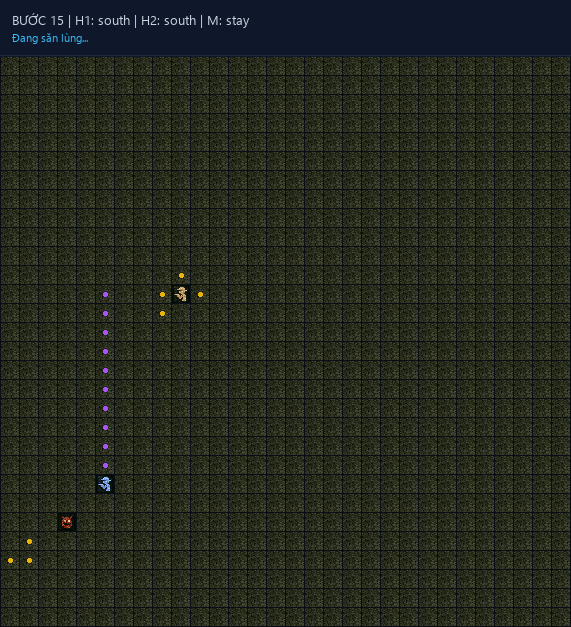
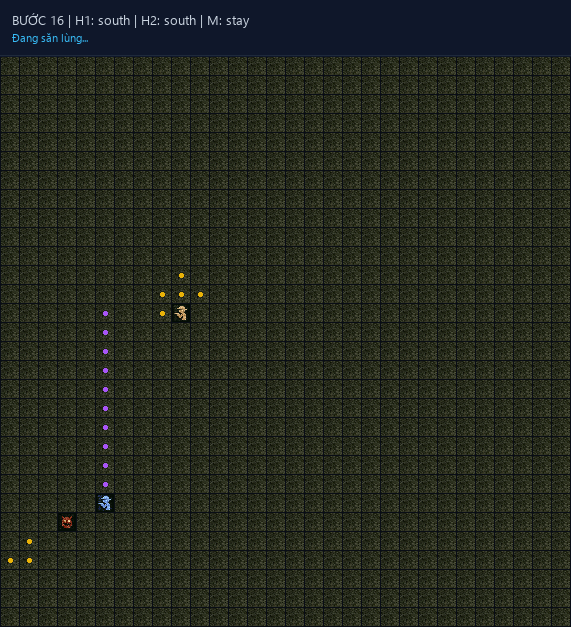
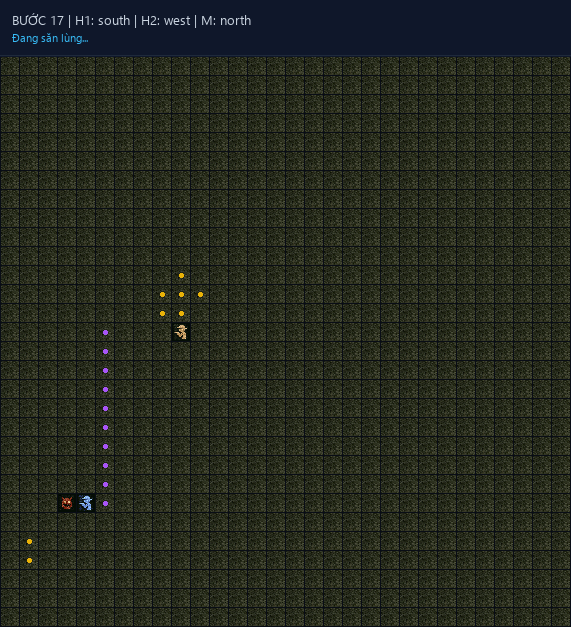
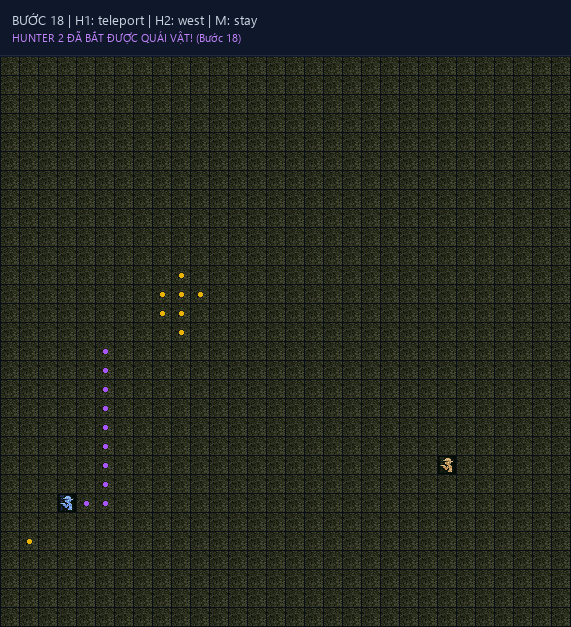

In [17]:
from gridhunt_visualizer import play_gridhunt, record_gridhunt_video, arena_environment_live

# Mô phỏng đấu đối kháng giữa Random Hunter (1) và Smart Hunter (2) trên lưới 20x20:
play_gridhunt(
    hunter_1_func=simple_randomized_hunter_agent_function,
    hunter_2_func=teleport_hunter_agent_function,
    monster_func=monster_agent_function_simple,
    n=30,
    max_steps=100,
    interval=500
)

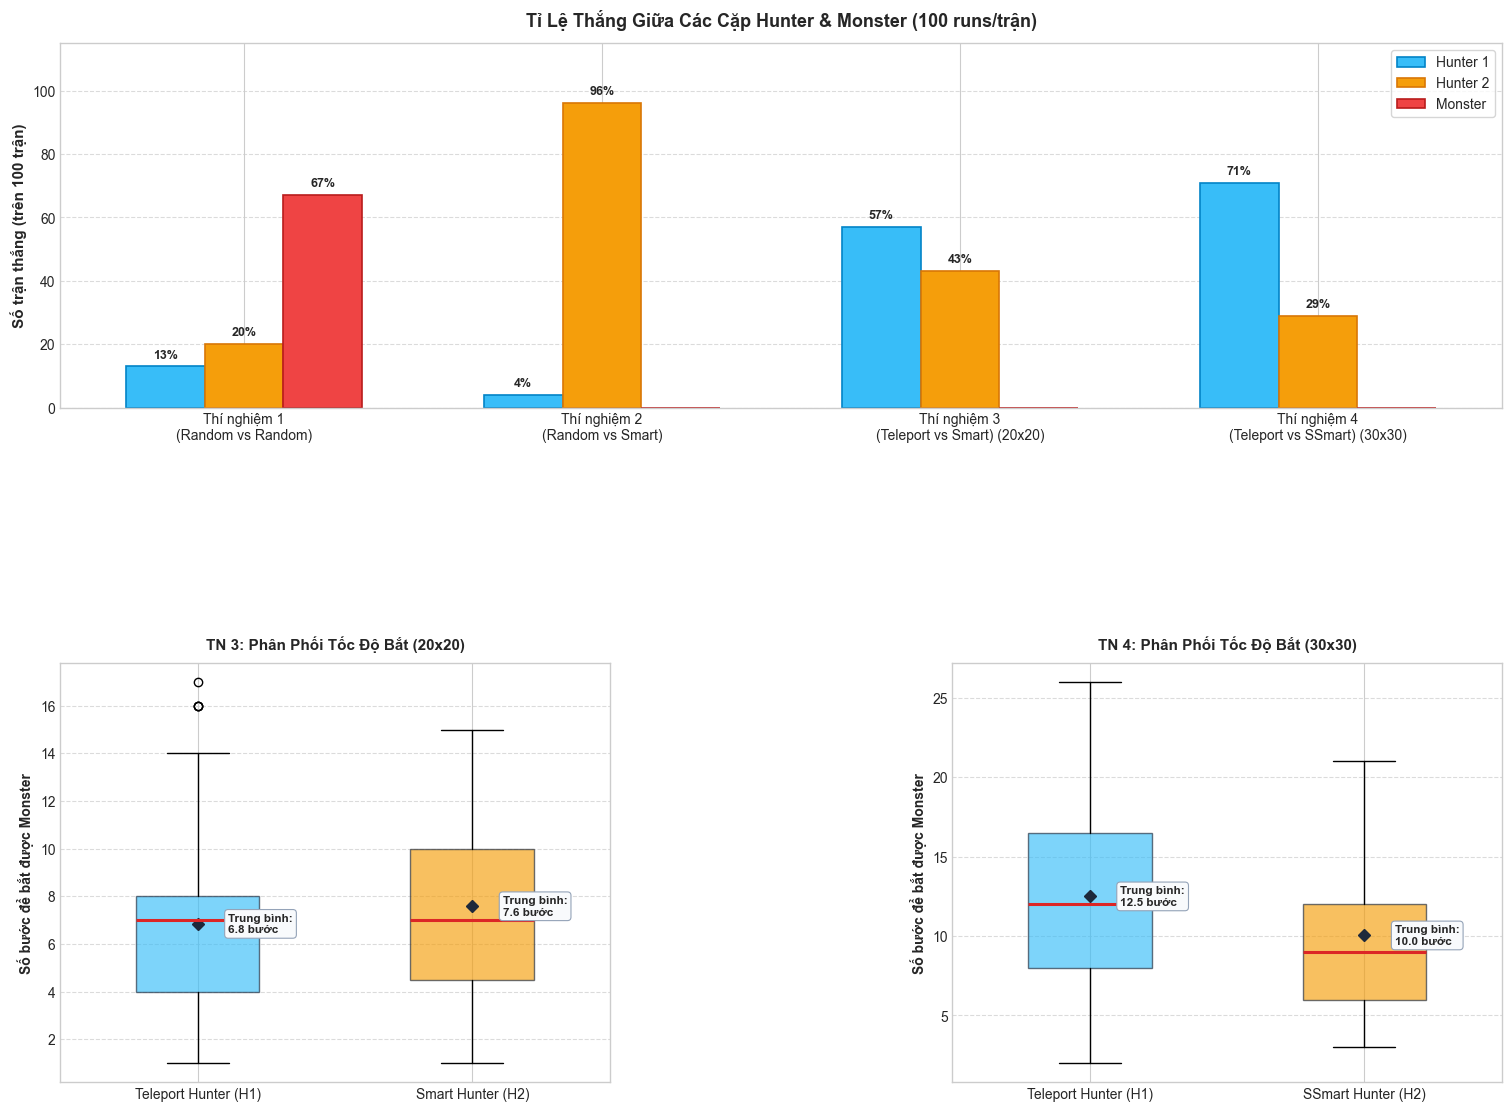

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. TRÍCH XUẤT THỐNG KÊ TỪ CÁC THÍ NGHIỆM
# ==============================================================================
def extract_stats(step_array):
    arr = np.array(step_array)
    h1_w = np.sum(arr[:, 0] == '1')
    h2_w = np.sum(arr[:, 0] == '2')
    m_w  = np.sum(arr[:, 0] == 'M')
    return h1_w, h2_w, m_w

# Lấy dữ liệu số trận thắng
h1_exp1, h2_exp1, m_exp1 = extract_stats(steps)   # Random vs Random
h1_exp2, h2_exp2, m_exp2 = extract_stats(steps1)  # Random vs Smart
h1_exp3, h2_exp3, m_exp3 = extract_stats(steps2)  # Teleport vs Smart (20x20)
h1_exp4, h2_exp4, m_exp4 = extract_stats(steps3)  # Teleport vs SSmart (30x30)

# 2. Lấy danh sách số bước đi khi Hunter thắng (loại bỏ nan khi Monster thắng)
steps_h1_exp3 = [int(s) for winner, s in steps2 if winner == '1' and str(s) != 'nan']
steps_h2_exp3 = [int(s) for winner, s in steps2 if winner == '2' and str(s) != 'nan']

steps_h1_exp4 = [int(s) for winner, s in steps3 if winner == '1' and str(s) != 'nan']
steps_h2_exp4 = [int(s) for winner, s in steps3 if winner == '2' and str(s) != 'nan']

# ==============================================================================
# THIẾT LẬP BỐ CỤC: HÀNG 1 (CỘT), HÀNG 2 (2 BOXPLOT)
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(15, 11), layout = 'constrained')
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15], hspace=0.35, wspace=0.2)

ax1 = fig.add_subplot(gs[0, :])  # Hàng trên: Chiếm trọn 2 cột
ax2 = fig.add_subplot(gs[1, 0])  # Hàng dưới bên trái: Thí nghiệm 3
ax3 = fig.add_subplot(gs[1, 1])  # Hàng dưới bên phải: Thí nghiệm 4

# ==============================================================================
# BIỂU ĐỒ 1 (TRÊN): TỈ LỆ THẮNG GIỮA CÁC ĐỐI THỦ
# ==============================================================================
match_labels = [
    'Thí nghiệm 1\n(Random vs Random)',
    'Thí nghiệm 2\n(Random vs Smart)',
    'Thí nghiệm 3\n(Teleport vs Smart) (20x20)',
    'Thí nghiệm 4\n(Teleport vs SSmart) (30x30)'
]
x = np.arange(len(match_labels))
width = 0.22

rects1 = ax1.bar(x - width, [h1_exp1, h1_exp2, h1_exp3, h1_exp4], width, label='Hunter 1', color='#38bdf8', edgecolor='#0284c7', lw=1.2)
rects2 = ax1.bar(x,         [h2_exp1, h2_exp2, h2_exp3, h2_exp4], width, label='Hunter 2', color='#f59e0b', edgecolor='#d97706', lw=1.2)
rects3 = ax1.bar(x + width, [m_exp1,  m_exp2,  m_exp3,  m_exp4], width, label='Monster',  color='#ef4444', edgecolor='#b91c1c', lw=1.2)

ax1.set_ylabel('Số trận thắng (trên 100 trận)', fontsize=11, fontweight='bold')
ax1.set_title('Tỉ Lệ Thắng Giữa Các Cặp Hunter & Monster (100 runs/trận)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xticks(x)
ax1.set_xticklabels(match_labels, fontsize=10)
ax1.set_ylim(0, 115)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Ghi số liệu trực tiếp trên từng cột
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        h = rect.get_height()
        if h > 0:
            ax1.annotate(f'{int(h)}%',
                         xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 4), textcoords="offset points",
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

# Hàm vẽ Boxplot tái sử dụng cho 2 ô bên dưới
def plot_speed_distribution(ax, data, labels, title):
    colors = ['#38bdf8', '#f59e0b']
    box = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.45,
                     medianprops=dict(color='#dc2626', linewidth=2.2))
    
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor('#1e293b')

    # Vẽ và chú thích giá trị trung bình (mean)
    for i, d in enumerate(data, start=1):
        if len(d) > 0:
            m = np.mean(d)
            ax.plot(i, m, marker='D', color='#1e293b', markersize=6)
            ax.annotate(f'Trung bình:\n{m:.1f} bước',
                        xy=(i, m), xytext=(22, 0), textcoords="offset points",
                        va='center', fontsize=8.5, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", fc="#f8fafc", ec="#94a3b8", lw=0.8))

    ax.set_ylabel('Số bước để bắt được Monster', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# ==============================================================================
# BIỂU ĐỒ 2 (DƯỚI TRÁI): THÍ NGHIỆM 3 (20x20)
# ==============================================================================
plot_speed_distribution(
    ax=ax2,
    data=[steps_h1_exp3, steps_h2_exp3],
    labels=['Teleport Hunter (H1)', 'Smart Hunter (H2)'],
    title='TN 3: Phân Phối Tốc Độ Bắt (20x20)'
)

# ==============================================================================
# BIỂU ĐỒ 3 (DƯỚI PHẢI): THÍ NGHIỆM 4 (30x30)
# ==============================================================================
plot_speed_distribution(
    ax=ax3,
    data=[steps_h1_exp4, steps_h2_exp4],
    labels=['Teleport Hunter (H1)', 'SSmart Hunter (H2)'],
    title='TN 4: Phân Phối Tốc Độ Bắt (30x30)'
)

plt.savefig('ket_qua_thi_nghiem.png', dpi=300, bbox_inches='tight')

plt.show()


## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

### Trả lời các vấn đề trên:
**1. What is your hunter's final strategy to choose actions. Why does it work well?**
- Thợ săn được cài đặt chiến lược truy đuổi tham lam theo khoảng cách **Manhattan** (*Greedy Manhattan Reflex*).

- Mỗi bước trước khi `Hunter` di chuyển sẽ tính lại khoảng cách hàng - cột so với `Monster` và đi theo trục có khoảng cách xa hơn để áp sát mục tiêu nhanh nhất.

**2. Do you use teleportation. Why and in what situation? Why not?**
- Hiện tại tôi đã thiết kế 2 agent, 1 trong số chúng có sử dụng `Teleport` và kế thừa cách săn `Monster` của agent còn lại.

- Việc dùng `Teleport` vì để có thể nhanh chóng rút ngắn được khoảng cách giữa `Hunter` với `Monster` khi vị trí ban đầu cảu chúng quá xa, khó tiếp cận và bắt được `Monster` trong số bước đã giới hạn trước.

- Nhưng nếu dùng `Teleport` 1 cách ngẫu nhiên có thể làm phản tác dụng (khi đã tiếp cận rất gần `Monster` thì lại dịch chuyển ra 1 khoảng rất xa), vì vậy tôi đã đặt điều kiện để `Hunter` được phép sử dụng dịch chuyển khi cách `Monster` quá xa (>30 ô) và chỉ có xác suất 30% có thể dịch chuyển để thử vận may xem có thể tiếp cận `Monster` nhanh hơn hay không.

**3. How does the arean size affects your hunter agent's performance?**
- Sàn càng to thì `Random Hunter` gần như không có khả năng chiến thắng (tỉ lệ thắng ~0%).

- Trong khi đó, `Smart Hunter` vẫn bắt được Monster 100%, vấn đề là số bước sẽ tăng lên tuyến tính theo độ lớn của sàn (`n`). 

- Khi kích thước sàn không quá lớn $( n \in [3; 15])$ thì 2 agent có/không có `Teleport` hoàn toàn không khác nhau(chúng chiến thắng chỉ dựa vào khoảng cách thợ săn nào được khởi tạo ban đầu và cách di chuyển của `Monster` là chủ yếu), nhưng khi tăng kích thước sàn ngày lúc càng lớn thì agent có khả năng `Teleport` hoàn toàn chiếm được ưu thế có thể bắt được `Monster` nhanh hơn nhiều so với agent không có khả năng `Teleport` vì nó có thể nhanh chóng tiếp cận mục tiêu ở 1 khoảng cách cực gần. 

![Experiment Image](ket_qua_thi_nghiem.png)

**The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.**

Hiện tại, `Monster agent` dù nhận được vị trí tọa độ của cả 2 `Hunter` nhưng nó được thiết lập di chuyển theo 4 hướng (`north`, `south`, `west`, `east`) hoặc đứng yên (`stay`) 1 cách ngẫu nhiên mà không có quy tắc nào cả. Vì thế nó không có khả năng chạy trốn hay né tránh trước sự truy đuổi của 2 thợ săn.

Để cải thiện vấn đề này tôi sẽ đề xuất 1 số hướng để cải thiện khả năng chạy trốn, tránh sự truy đuổi của các `Hunter agent`:

- *Dùng Hàm đánh giá* (Heuristic): Thay vì đi ngẫu nhiên, Monster sẽ chấm điểm các ô xung quanh và chọn ô an toàn nhất trước khi đi.
- *Chiến lược Maximin*: Luôn ưu tiên chọn hướng đi giúp nới rộng khoảng cách lớn nhất với thợ săn đang đứng gần mình nhất.
- *Tránh bẫy địa hình*: Phạt điểm nặng nếu di chuyển vào sát mép tường hoặc 4 góc bàn cờ để tránh bị dồn vào đường cùng (corner trap).
- *Né tránh vuông góc*: Nếu thợ săn tiến đến theo đường thẳng (cùng hàng/cột), Monster ưu tiên tạt sang ngang hoặc dọc để thoát khỏi hướng truy cản trực diện.
- *Dự đoán tương lai* (Nâng cao): Sử dụng thuật toán tìm kiếm Minimax hoặc Học tăng cường (Q-Learning) để dự đoán trước bước đi của thợ săn và lên kế hoạch tẩu thoát dài hạn.

# More Work (optional)

* Improve the monster agent so it tries to run away from the hunters. Don;t make the monster too fast or the hunters will never be able to catch it.
* How could the two hunter agents work together? You need to think about information sharing. This can be implemented by the two agent functions sharing a single Python class or the environment could be expanded by an action "shout" that lets the other agent perceive a message.